## Histogram

In [33]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

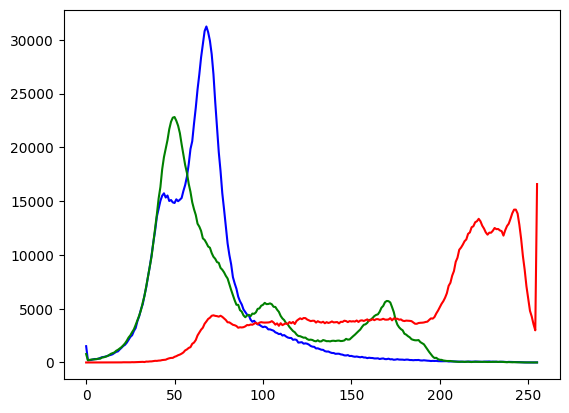

In [41]:
image = cv.imread("./notebook/images/4seasons.jpg")
h, w, c = image.shape
mask = np.zeros(image.shape[0:2], np.uint8)
mask[0:int(h / 2), 0:int(w / 2)] = 255

colors = ["b", "g", "r"]
for i, col in enumerate(colors):
    histogram = cv.calcHist([image], [i], mask, [256], [0, 256])
    plt.plot(histogram, color=col)

gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
histogram = cv.calcHist([gray_image], [0], None, [256], [0, 256])

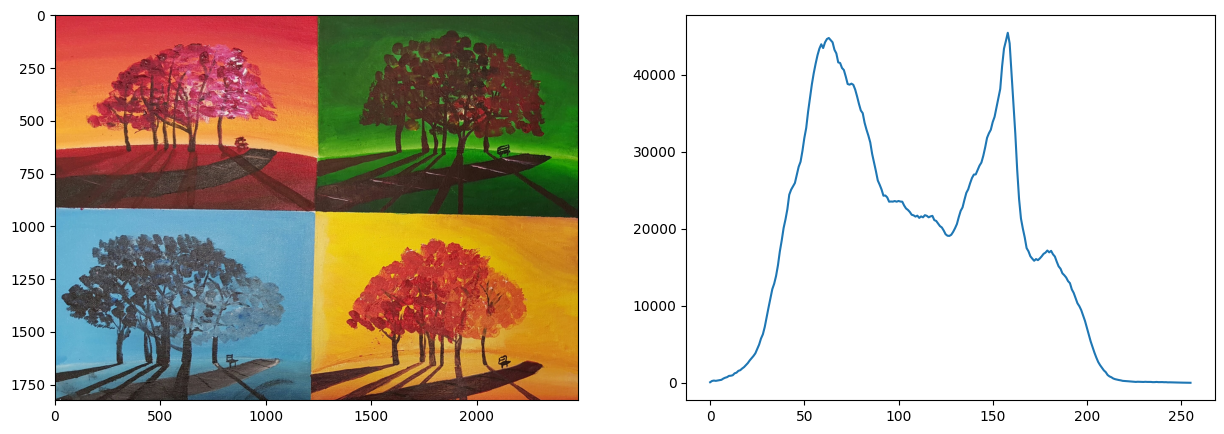

In [42]:
plt.figure(figsize=(15, 5))
plt.subplot(121), plt.imshow(image[..., ::-1], cmap="gray")
plt.subplot(122), plt.plot(histogram)
plt.show()

## Increasing Contrast(Equalizing Histogram)

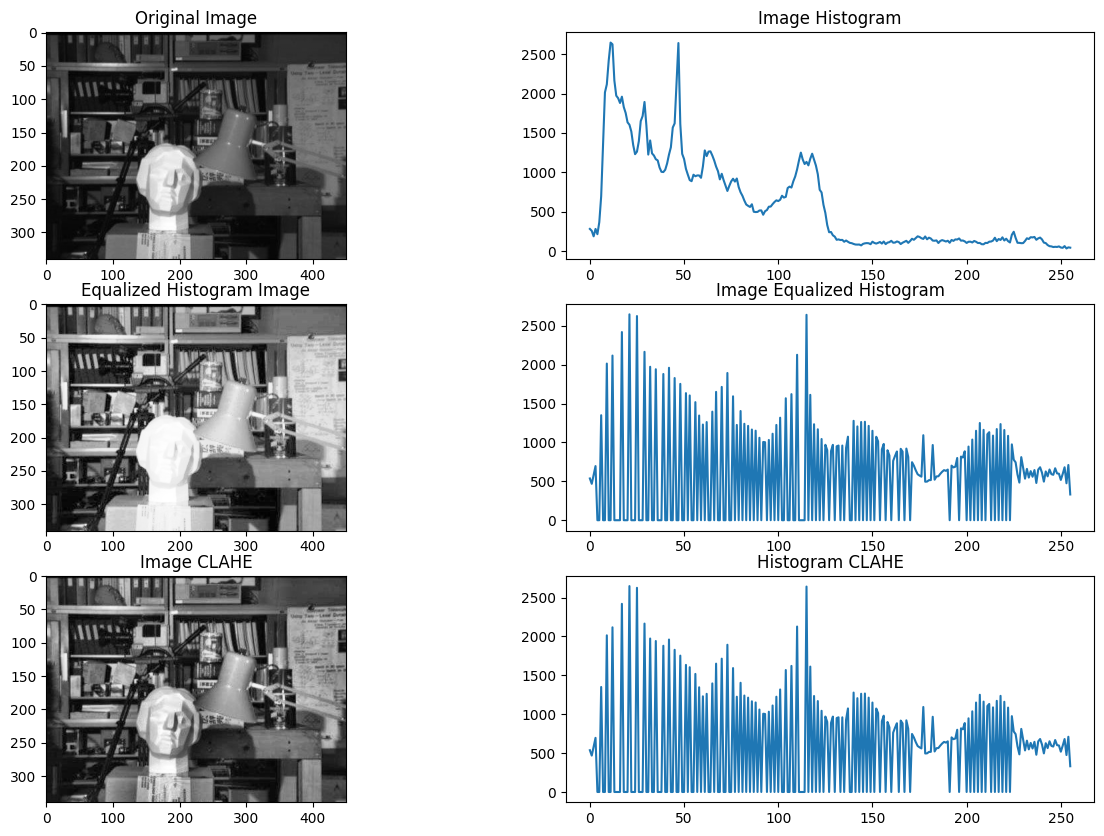

In [58]:
image = cv.imread("./notebook/images/statue.jpg", 0)
image_histogram = cv.calcHist([image], [0], None, [256], [0, 256])
equalized_histogram = cv.equalizeHist(image)
img_equal_hist = cv.calcHist([equalized_histogram], [0], None, [256], [0, 256])

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl1 = clahe.apply(image)
cl1_equal_hist = cv.calcHist([cl1], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 10))
plt.subplot(321), plt.imshow(image, cmap="gray"), plt.title("Original Image")
plt.subplot(322), plt.plot(image_histogram), plt.title("Image Histogram")
plt.subplot(323), plt.imshow(equalized_histogram, cmap="gray"), plt.title("Equalized Histogram Image")
plt.subplot(324), plt.plot(img_equal_hist), plt.title("Image Equalized Histogram")
plt.subplot(325), plt.imshow(cl1, cmap="gray"), plt.title("Image CLAHE")
plt.subplot(326), plt.plot(img_equal_hist), plt.title("Histogram CLAHE")
plt.show()